In [1]:
import feos, pandas as pd, si_units as si, matplotlib.pyplot as plt, numpy as np, os
import seaborn as sns

sns.set_context('talk')
sns.set_palette('Dark2')
sns.set_style('ticks')
colors = sns.palettes.color_palette('Dark2', 8)

In [2]:
parameters = feos.Parameters.from_json(["helium"], "parameters.json")
            # binary_path="aasen2020_binary.json")

parameters

|component|molarweight|m|sigma|epsilon_k|lr|la|fh|
|-|-|-|-|-|-|-|-|
|helium|4.002601643881807|1.0|2.7443|5.4195|9.0|6.0|1|

In [3]:
saftqmie = feos.EquationOfState.pcsaft(parameters)

In [4]:
phase_diagram = feos.PhaseDiagram.pure(saftqmie, min_temperature=1*si.KELVIN, npoints=100)

In [5]:
df = pd.DataFrame(phase_diagram.to_dict(feos.Contributions.Residual))
vapor_density = df['density vapor']
liquid_density = df['density liquid']
temperature = df.temperature

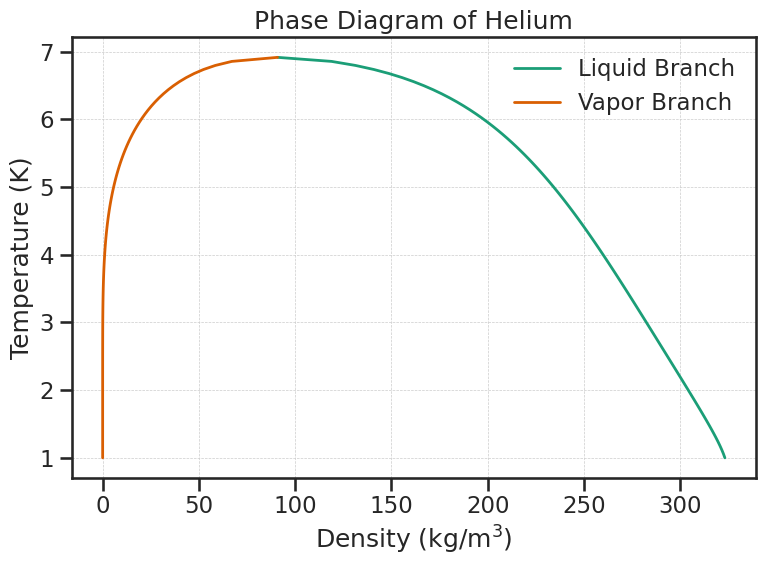

In [6]:
M_He = 0.004002602  # kg/mol

liquid_density_kgm3 = (liquid_density * M_He)
vapor_density_kgm3  = (vapor_density  * M_He)

plt.figure(figsize=(8,6))

plt.plot(liquid_density_kgm3, temperature, label='Liquid Branch', linewidth=2)
plt.plot(vapor_density_kgm3,  temperature, label='Vapor Branch', linewidth=2)

plt.xlabel(r'Density (kg/m$^3$)')
plt.ylabel(r'Temperature (K)')
plt.title('Phase Diagram of Helium')
plt.legend(frameon=False)
plt.grid(True, which='both', ls='--', lw=0.5)
plt.tight_layout()
plt.show()
